Question 13 : Importation du dataframe contenant les surfaces depuis le fichier numpy sauvegardé

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# allow_pickle = True permet de charger des objects de tout type (int, float, etc)
surfaces = np.load("areas.npy",  allow_pickle=True)
print(surfaces)

[[1990 'ARA' 3731289.895671272 94357.49607363011 3802925.694171712
  330791.80779152765 7137.3359746891]
 [2000 'ARA' 3729285.094017935 95332.5654720033 3792905.1849504435
  341882.9718241794 7096.4134176912]
 [2006 'ARA' 3702212.1157274246 95636.15844683567 3791894.620536117
  367157.5776584224 6322.6348341267]
 [2012 'ARA' 3614112.3942739223 88804.59001296855 3759010.9397859965
  387988.7617995181 5946.2159521869]
 [1990 'BRE' 367791.9944926315 488204.24669310165 2331140.5654340307
  161527.77482025392 81142.1033964552]
 [2000 'BRE' 367596.04582483217 488518.1701913716 2320392.5086811716
  172106.95074414197 81193.0093953952]
 [2006 'BRE' 363757.26782008866 488581.87802035204 2317788.1031776927
  178312.92010553813 81366.51571300438]
 [2012 'BRE' 363338.42232585757 487810.7718863391 2302788.69446549
  193470.81107443164 82397.98508417475]]


Questions 14 à 16 : On convertit le dataframe importé au format MultiIndex avec les années et les régions en ligne

In [25]:
land_cover = [
    "Forêts et milieux semi-naturels",
    "Surfaces en eau",
    "Territoires agricoles",
    "Territoires artificialisés",
    "Zones humides"
]

index = pd.MultiIndex.from_arrays(
    [surfaces[:, 1], surfaces[:, 0]],
    names=["region", "annee"]
)

df = pd.DataFrame(
    surfaces[:, 2:],
    index=index,
    columns=land_cover
)

df

Forêts et milieux semi-naturels Surfaces en eau  \
region annee                                                   
ARA    1990                   3731289.895671    94357.496074   
       2000                   3729285.094018    95332.565472   
       2006                   3702212.115727    95636.158447   
       2012                   3614112.394274    88804.590013   
BRE    1990                    367791.994493   488204.246693   
       2000                    367596.045825   488518.170191   
       2006                     363757.26782    488581.87802   
       2012                    363338.422326   487810.771886   

             Territoires agricoles Territoires artificialisés Zones humides  
region annee                                                                 
ARA    1990         3802925.694172              330791.807792   7137.335975  
       2000          3792905.18495              341882.971824   7096.413418  
       2006         3791894.620536              367157.577658   6322.634834  
       2012         3759010.939786                387988.7618   5946.215952  
BRE    1990         2331140.565434               161527.77482  81142.103396  
       2000         2320392.508681              172106.950744  81193.009395  
       2006         2317788.103178              178312.920106  81366.515713  
       2012         2302788.694465              193470.811074  82397.985084

Question 17 : Le code ci-dessous permet d'afficher les surfaces d'occupation des sols pour l'année 1990 et la région Auvergne Rhones Alpes 'ARA'

In [26]:
df.loc['ARA', 1990]

Forêts et milieux semi-naturels    3731289.895671
Surfaces en eau                      94357.496074
Territoires agricoles              3802925.694172
Territoires artificialisés          330791.807792
Zones humides                         7137.335975
Name: (ARA, 1990), dtype: object

Question 18 : On affiche l'évolution des Territoires agricoles en ARA

<Axes: title={'center': 'Evolution des terres agricoles en ARA'}, xlabel='Années', ylabel='Surface en ha'>

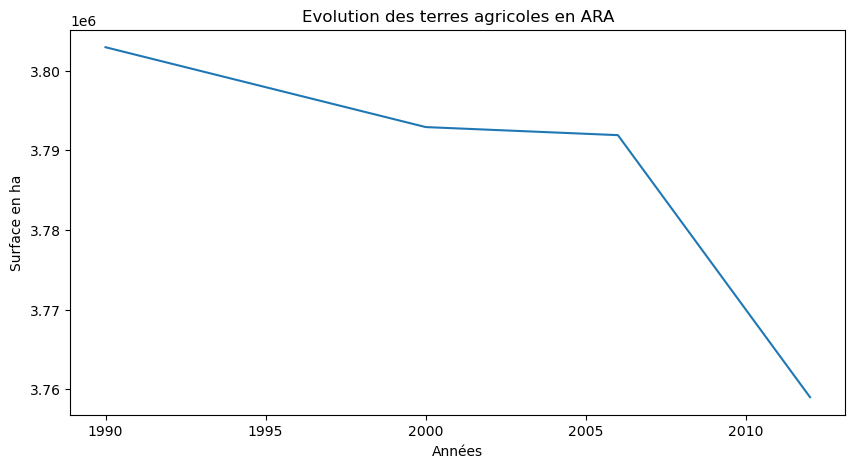

In [27]:
df.loc['ARA']['Territoires agricoles'].plot(
    kind='line',
    figsize=(10, 5),
    title='Evolution des terres agricoles en ARA',
    ylabel='Surface en ha',
    xlabel='Années'
    )

Question 19 : On affiche sur le même graphique l'évolution des terres agricoles dans les deux régions

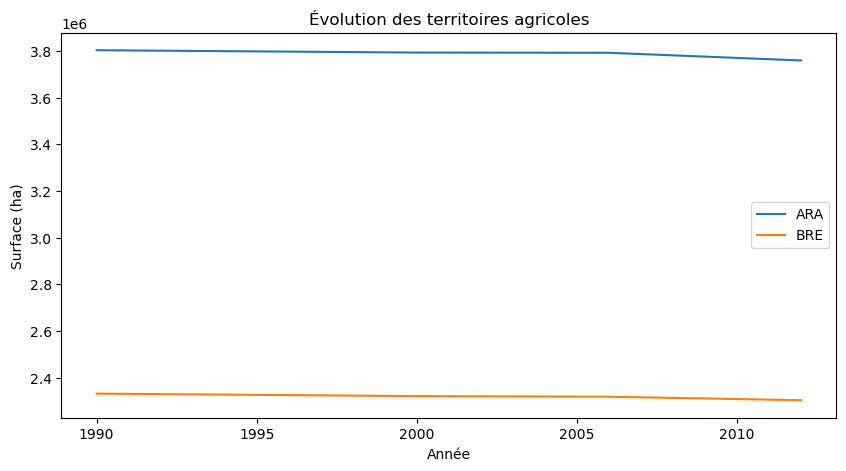

In [29]:
df.loc["ARA"]["Territoires agricoles"].plot(
    kind="line",
    figsize=(10, 5),
    label="ARA"
)

df.loc["BRE"]["Territoires agricoles"].plot(
    kind="line",
    figsize=(10, 5),
    label="BRE"
)

plt.title("Évolution des territoires agricoles")
plt.xlabel("Année")
plt.ylabel("Surface (ha)")
plt.legend()
plt.show()

Question 20 : On transpose le dataframe et on affiche la répartition des sols en ARA en 1990. Réponse à la question ci dessous

C:\Users\Antonin\AppData\Local\Temp\ipykernel_24060\1524349264.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ara_transpose[1990].plot(


<Axes: title={'center': 'Diagramme circulaire montrant la répartition des sols en 1990'}, ylabel='1990'>

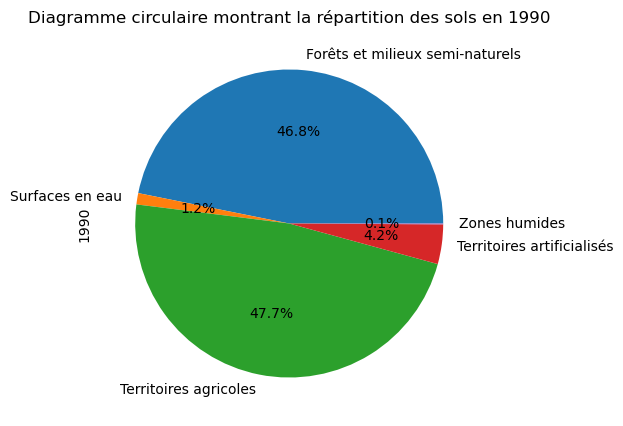

In [32]:
df_ara = df.loc['ARA']

df_ara_transpose = df_ara.T
df_ara_transpose[1990].plot(
    kind='pie',
    figsize=(10, 5),
    title='Diagramme circulaire montrant la répartition des sols en 1990',
    autopct="%1.1f%%"
    )

Les territoires agricoles sont la classe de sol prédominante en Auvergne Rhones Alpes en 1990.